In [ ]:
import os

if not os.path.exists("/content/dataset"):
    !pip install datasets transformers[torch] librosa evaluate jiwer accelerate torchaudio
else:
    print("Dependencies already installed.")


In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/ne_np_female.zip"
extract_path = "/content/dataset"

if not os.path.exists(extract_path):
    os.makedirs(extract_path)
    !unzip -q {zip_path} -d {extract_path}
    print("Extraction Complete!")
else:
    print("Dataset already extracted.")

Mounted at /content/drive
unzip:  cannot find or open /content/drive/MyDrive/ne_np_female.zip, /content/drive/MyDrive/ne_np_female.zip.zip or /content/drive/MyDrive/ne_np_female.zip.ZIP.
Extraction Complete!


In [ ]:
import pandas as pd
import os
from datasets import Dataset, Audio

audio_dir = "/content/drive/MyDrive/ne_np_female/wavs"
tsv_path = "/content/drive/MyDrive/ne_np_female/line_index.tsv"

df = pd.read_csv(tsv_path, sep="\t", header=None, names=["audio_id", "sentence"])

df["audio"] = df["audio_id"].apply(lambda x: os.path.join(audio_dir, f"{x}.wav"))

df = df[df["audio"].apply(os.path.exists)].reset_index(drop=True)

print(f"Total valid audio files found: {len(df)}")
print(f"Sample path: {df['audio'].iloc[0]}")

dataset = Dataset.from_pandas(df)
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

dataset = dataset.train_test_split(test_size=0.1)

Total valid audio files found: 2064
Sample path: /content/drive/MyDrive/ne_np_female/wavs/nep_0258_0119737288.wav


In [ ]:
!python --version
!pip show torch
!pip show torchaudio

Python 3.13.15
Name: torch
Version: 2.11.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.13/dist-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cudnn-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvshmem-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision
Name: torchaudio
Version: 2.11.0+cu128
Summary: An audio package for PyTorch
Home-page: https://github.com/pytorch/audio
Author: Soumith Chintala, David Pollack, Sean Naren, Peter Goldsborough, Moto Hira, Caroline Chen, Jeff Hwang, Zhaoheng Ni, Xiaohui Zhang
Author-email: soumith@pytorch.org
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: 
Required-by: 


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
import torchaudio

print("TorchAudio:", torchaudio.__version__)

TorchAudio: 2.11.0+cu128


In [ ]:
from transformers import WhisperFeatureExtractor, WhisperTokenizer, WhisperProcessor

model_id = "openai/whisper-large-v3-turbo"

feature_extractor = WhisperFeatureExtractor.from_pretrained(model_id)
tokenizer = WhisperTokenizer.from_pretrained(model_id, language="nepali", task="transcribe")
processor = WhisperProcessor.from_pretrained(model_id, language="nepali", task="transcribe")

def prepare_dataset(batch):
    audio = batch["audio"]
    batch["input_features"] = feature_extractor(audio["array"], sampling_rate=audio["sampling_rate"]).input_features[0]
    batch["labels"] = tokenizer(batch["sentence"]).input_ids
    return batch

dataset = dataset.map(
    prepare_dataset,
    remove_columns=dataset.column_names["train"],
    num_proc=1
)

dataset.save_to_disk("/content/drive/MyDrive/processed_nepali_dataset_large")
print("Large-v3 Dataset processed and saved to Drive!")

Map:   0%|          | 0/1857 [00:00<?, ? examples/s]

Map:   0%|          | 0/207 [00:00<?, ? examples/s]

Saving the dataset (0/6 shards):   0%|          | 0/1857 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/207 [00:00<?, ? examples/s]

Large-v3 Dataset processed and saved to Drive!


In [ ]:
import evaluate
import numpy as np

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = tokenizer.pad_token_id

    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = 100 * wer_metric.compute(predictions=pred_str, references=label_str)
    cer = 100 * cer_metric.compute(predictions=pred_str, references=label_str)

    return {
        "wer": wer,
        "cer": cer
    }

In [ ]:
import torch
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

In [ ]:
!pip uninstall -y torchao peft

!pip install torchao==0.18.0 peft==0.12.0 bitsandbytes transformers datasets accelerate evaluate jiwer -q

import peft
import torchao
print(f" PEFT version: {peft.__version__}")
print(f" Torchao version: {torchao.__version__}")

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 15.0 MB/s eta 0:00:00


W0902 11:26:47.782000 7107 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0902 11:26:48.156000 7107 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


 PEFT version: 0.12.0
 Torchao version: 0.18.0


In [ ]:
!pip install -U transformers peft accelerate bitsandbytes datasets evaluate jiwer

In [ ]:
import os
import torch
import evaluate
import glob
import warnings
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from datasets import load_from_disk
from transformers import (
    WhisperForConditionalGeneration,
    WhisperProcessor,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

model_id = "openai/whisper-large-v3-turbo"
SAVE_PATH_LORA = "/content/drive/MyDrive/nepali_whisper_large_v3_lora"
PROCESSED_DATA_PATH = "/content/drive/MyDrive/processed_nepali_dataset_large"

NEPALI_CORRECTION_DICT = {
    "नेपालि": "नेपाली", "तपाँई": "तपाईं", "हजुरबा": "हजुरबुवा", "तिमि": "तिमी",
    "तिमिको": "तिमीको", "तिमीलाइ": "तिमीलाई", "तिमिले": "तिमीले", "उहा": "उहाँ",
    "उहाको": "उहाँको", "उहालाई": "उहाँलाई", "उहाले": "उहाँले", "हामि": "हामी",
    "हामिको": "हामीको", "हामिलाई": "हामीलाई", "हामिले": "हामीले", "उनि": "उनी",
    "उनिको": "उनीको", "उनिलाई": "उनीलाई", "उनिले": "उनीले", "तिनि": "तिनी",
    "तिनिको": "तिनीको", "तिनिलाई": "तिनीलाई", "तिनिले": "तिनीले", "गळत": "गलत",
    "गळो": "गलत", "गलतट": "गलत", "गलतछ": "गलत", "काठमाडौ": "काठमाडौँ",
    "काठमाण्डौ": "काठमाडौँ", "काठमाण्डु": "काठमाडौँ", "पोखरामा": "पोखरामा",
    "ललितपुर": "ललितपुर", "भक्तपुर": "भक्तपुर", "राम्रोसग": "राम्रोसँग",
    "हाम्रोसग": "हाम्रोसँग", "तिम्रोसग": "तिम्रोसँग", "तपाईसग": "तपाईंसँग",
    "उहासग": "उहाँसँग", "उनीसग": "उनीसँग", "यससग": "यससँग", "त्यससग": "त्यससँग",
    "गर्नुहोस": "गर्नुहोस्", "आउनुहोस": "आउनुहोस्", "जानुहोस": "जानुहोस्",
    "खानुहोस": "खानुहोस्", "बस्नुहोस": "बस्नुहोस्", "उठ्नुहोस": "उठ्नुहोस्",
    "हेर्नुहोस": "हेर्नुहोस्", "सुन्नुहोस": "सुन्नुहोस्", "भन्नुहोस": "भन्नुहोस्",
    "लेख्नुहोस": "लेख्नुहोस्", "पढ्नुहोस": "पढ्नुहोस्", "सिक्नुहोस": "सिक्नुहोस्",
    "बोल्नुहोस": "बोल्नुहोस्", "हाँस्नुहोस": "हाँस्नुहोस्", "रुनुहोस": "रुने गर्नुहोस्",
    "धोइदिनुहोस": "धोइदिनुहोस्", "नेपालिह": "नेपाली", "काठमाडौं": "काठमाडौँ",
    "धन्यबाद": "धन्यवाद", "नमस्ते": "नमस्ते", "पर्‍यो": "पर्यो",
    "कुराहरु": "कुराहरू", "साथीहरु": "साथीहरू", "मान्छेहरु": "मान्छेहरू",
}

def apply_nepali_corrections(text):
    for wrong, right in NEPALI_CORRECTION_DICT.items():
        text = text.replace(wrong, right)
    return text

processor = WhisperProcessor.from_pretrained(model_id, language="nepali", task="transcribe")
dataset = load_from_disk(PROCESSED_DATA_PATH)

@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]
        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    pred_str = [apply_nepali_corrections(s) for s in pred_str]
    return {
        "wer": 100 * wer_metric.compute(predictions=pred_str, references=label_str),
        "cer": 100 * cer_metric.compute(predictions=pred_str, references=label_str)
    }

print("Loading Model...")
bnb_config = BitsAndBytesConfig(load_in_8bit=True)
model = WhisperForConditionalGeneration.from_pretrained(model_id, quantization_config=bnb_config, device_map="auto")

model.config.use_cache = False

model = prepare_model_for_kbit_training(model)
model.enable_input_require_grads()

config = LoraConfig(
    r=32, lora_alpha=64, target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05, bias="none"
)
model = get_peft_model(model, config)

model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(language="nepali", task="transcribe")
model.config.suppress_tokens = []


training_args = Seq2SeqTrainingArguments(
    output_dir=SAVE_PATH_LORA,
    per_device_train_batch_size=1,        
    gradient_accumulation_steps=16,      
    learning_rate=1e-4,
    warmup_steps=50,
    max_steps=1000,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    logging_steps=1,                     
    predict_with_generate=True,
    generation_max_length=225,
    fp16=True,
    gradient_checkpointing=False,        
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    save_total_limit=1,
    report_to="none",
    remove_unused_columns=False,
    label_names=["labels"]
)

trainer = Seq2SeqTrainer(
    args=training_args, model=model, train_dataset=dataset["train"],
    eval_dataset=dataset["test"], data_collator=data_collator,
    compute_metrics=compute_metrics, processing_class=processor.feature_extractor,
)

checkpoint = None
if os.path.exists(SAVE_PATH_LORA):
    checkpoints = glob.glob(os.path.join(SAVE_PATH_LORA, "checkpoint-*"))
    if checkpoints:
        checkpoint = max(checkpoints, key=os.path.getctime)
        print(f"Resuming from: {checkpoint}")

print("\n" + "="*50)
print("TRAINING STARTING.")
print("="*50 + "\n")

trainer.train(resume_from_checkpoint=checkpoint)

trainer.save_model(SAVE_PATH_LORA)
processor.save_pretrained(SAVE_PATH_LORA)
print(f"DONE! Saved everything to {SAVE_PATH_LORA}")

Loading Model...


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]


TRAINING STARTING.

{'loss': '21.82', 'grad_norm': 'nan', 'learning_rate': '0', 'epoch': '0.008616'}
{'loss': '20.82', 'grad_norm': 'nan', 'learning_rate': '2e-06', 'epoch': '0.01723'}
{'loss': '23.39', 'grad_norm': 'nan', 'learning_rate': '4e-06', 'epoch': '0.02585'}
{'loss': '21.33', 'grad_norm': '30.05', 'learning_rate': '6e-06', 'epoch': '0.03446'}
{'loss': '19.72', 'grad_norm': '27.78', 'learning_rate': '8e-06', 'epoch': '0.04308'}
{'loss': '20.99', 'grad_norm': 'nan', 'learning_rate': '1e-05', 'epoch': '0.0517'}
{'loss': '19.88', 'grad_norm': '31.38', 'learning_rate': '1.2e-05', 'epoch': '0.06031'}
{'loss': '19.52', 'grad_norm': '29.4', 'learning_rate': '1.4e-05', 'epoch': '0.06893'}
{'loss': '21.5', 'grad_norm': '31.48', 'learning_rate': '1.6e-05', 'epoch': '0.07754'}
{'loss': '19.38', 'grad_norm': '28.71', 'learning_rate': '1.8e-05', 'epoch': '0.08616'}
{'loss': '23.77', 'grad_norm': '44.63', 'learning_rate': '2e-05', 'epoch': '0.09478'}
{'loss': '23.83', 'grad_norm': '37.48',

In [ ]:
# training stopped due to crash
trainer.save_model(SAVE_PATH_LORA)
processor.save_pretrained(SAVE_PATH_LORA)
print("Best model has been saved to:", SAVE_PATH_LORA)

NameError: name 'trainer' is not defined

In [ ]:
import torch
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from peft import PeftModel

model_path = "/content/drive/MyDrive/nepali_whisper_large_v3_lora"
base_model_id = "openai/whisper-large-v3-turbo"

processor = WhisperProcessor.from_pretrained(model_path)

base_model = WhisperForConditionalGeneration.from_pretrained(base_model_id, torch_dtype=torch.float16, device_map="cuda")

model = PeftModel.from_pretrained(base_model, model_path)
model = model.merge_and_unload()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import glob

SAVE_PATH_LORA = "/content/drive/MyDrive/nepali_whisper_large_v3_lora"

checkpoints = glob.glob(os.path.join(SAVE_PATH_LORA, "checkpoint-*"))

if not checkpoints:
    print("No checkpoints found! Please check if your Drive is mounted and the folder path is correct.")
else:
    checkpoints.sort(key=lambda x: int(x.split('-')[-1]))
    latest_checkpoint = checkpoints[-1]

    checkpoint_names = [os.path.basename(cp) for cp in checkpoints]
    print(f"Found the following checkpoints: {checkpoint_names}")
    print(f"Selecting the LATEST one from today: {latest_checkpoint}")

    print("Copying files to main folder...")
    for item in os.listdir(latest_checkpoint):
        src_path = os.path.join(latest_checkpoint, item)
        dst_path = os.path.join(SAVE_PATH_LORA, item)
        if os.path.isfile(src_path):
            shutil.copy2(src_path, dst_path)

    print("="*50)
    print(f"SUCCESS! Your latest model ({os.path.basename(latest_checkpoint)}) is now ready.")
    print("This version contains all the learning from your many hours of training.")
    print("="*50)

Found the following checkpoints: ['checkpoint-100', 'checkpoint-400']
Selecting the LATEST one from today: /content/drive/MyDrive/nepali_whisper_large_v3_lora/checkpoint-400
Copying files to main folder... please wait.
SUCCESS! Your latest model (checkpoint-400) is now ready.
This version contains all the learning from your many hours of training.


In [ ]:
import shutil
from google.colab import files

zip_filename = "nepali_whisper_final_model"

print("Zipping the model folder... this might take a minute.")
shutil.make_archive(zip_filename, 'zip', SAVE_PATH_LORA)

print("Downloading now...")
files.download(f"{zip_filename}.zip")

Zipping the model folder... this might take a minute.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import json
import os

SAVE_PATH_LORA = "/content/drive/MyDrive/nepali_whisper_large_v3_lora"

state_file = os.path.join(SAVE_PATH_LORA, "trainer_state.json")

with open(state_file, "r", encoding="utf-8") as f:
    state = json.load(f)

for x in state["log_history"]:
    if "eval_wer" in x or "eval_cer" in x:
        print(
            f"Step {x.get('step')}: "
            f"WER={x.get('eval_wer'):.2f}% | "
            f"CER={x.get('eval_cer'):.2f}% | "
            f"Loss={x.get('eval_loss')}"
        )

Step 100: WER=58.53% | CER=16.16% | Loss=0.32551008462905884
Step 200: WER=49.10% | CER=11.60% | Loss=0.2633771598339081
Step 300: WER=45.54% | CER=10.59% | Loss=0.23998093605041504
Step 400: WER=44.29% | CER=10.24% | Loss=0.22861149907112122


EVALUATION RESULTS
Step  100 | WER:    58.53% | CER:    16.16%
Step  200 | WER:    49.10% | CER:    11.60%
Step  300 | WER:    45.54% | CER:    10.59%
Step  400 | WER:    44.29% | CER:    10.24%

BEST RESULTS
Best WER: 44.29% at step 400
Best CER: 10.24% at step 400


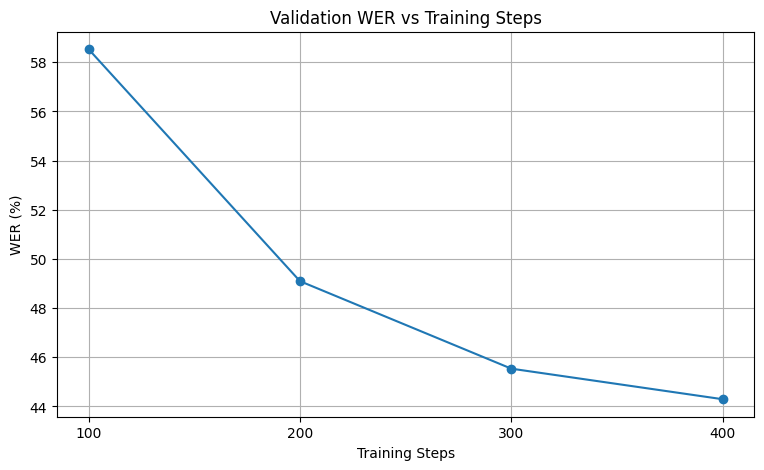

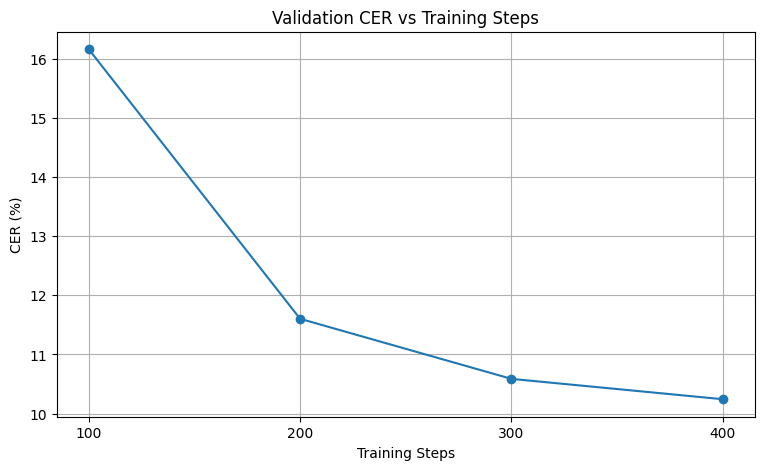

In [ ]:
import json
import os
import matplotlib.pyplot as plt

SAVE_PATH_LORA = "/content/drive/MyDrive/nepali_whisper_large_v3_lora"

with open(os.path.join(SAVE_PATH_LORA, "trainer_state.json"), "r", encoding="utf-8") as f:
    state = json.load(f)

eval_logs = [
    x for x in state["log_history"]
    if "eval_wer" in x and "eval_cer" in x
]

steps = [x["step"] for x in eval_logs]
wers = [x["eval_wer"] for x in eval_logs]
cers = [x["eval_cer"] for x in eval_logs]

print("=" * 60)
print("EVALUATION RESULTS")
print("=" * 60)

for step, wer, cer in zip(steps, wers, cers):
    print(f"Step {step:4d} | WER: {wer:8.2f}% | CER: {cer:8.2f}%")

best_wer_index = wers.index(min(wers))
best_cer_index = cers.index(min(cers))

print("\n" + "=" * 60)
print("BEST RESULTS")
print("=" * 60)

print(
    f"Best WER: {wers[best_wer_index]:.2f}% "
    f"at step {steps[best_wer_index]}"
)

print(
    f"Best CER: {cers[best_cer_index]:.2f}% "
    f"at step {steps[best_cer_index]}"
)


# WER
plt.figure(figsize=(9, 5))
plt.plot(steps, wers, marker="o")
plt.xlabel("Training Steps")
plt.ylabel("WER (%)")
plt.title("Validation WER vs Training Steps")
plt.grid(True)
plt.xticks(steps)
plt.show()


# CER
plt.figure(figsize=(9, 5))
plt.plot(steps, cers, marker="o")
plt.xlabel("Training Steps")
plt.ylabel("CER (%)")
plt.title("Validation CER vs Training Steps")
plt.grid(True)
plt.xticks(steps)
plt.show()